In [30]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from plant_shape_analysis.dataloaders.trackplant3D import PlantSequencesDataset, LeafSequencesDataset

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data inspection

In [2]:
dataset_path = Path("../data/TrackPlant3D")

### Plant sequences

In [3]:
plant_dataset = PlantSequencesDataset(dataset_path)

print(f"Number of sequences: {len(plant_dataset)}")
print(f"Available sequences: {plant_dataset.get_sequence_names()[:5]}")  # Show first 5

# Count scans with dense point clouds
sequences_with_dense_points = 0
scans_with_dense_points = 0
total_scans = 0

for seq in plant_dataset:
    scans_with_dense_points_in_seq = 0
    for scan in seq:
        total_scans += 1
        if scan['dense_points'] is not None:
            scans_with_dense_points += 1
            scans_with_dense_points_in_seq += 1
    if scans_with_dense_points_in_seq == len(seq):
        sequences_with_dense_points += 1

print(f"Number of sequences with dense point clouds: {sequences_with_dense_points}")
print(f"Total number of scans: {total_scans}")
print(f"Number of scans with dense point clouds: {scans_with_dense_points}")
print(f"Percentage of scans with dense points: {scans_with_dense_points/total_scans*100:.1f}%")

Number of sequences: 43
Available sequences: ['maize_control_plant1', 'maize_control_plant3', 'maize_control_plant2', 'sorghum_shade_plant2', 'sorghum_heat_plant1']
Number of sequences with dense point clouds: 6
Total number of scans: 378
Number of scans with dense point clouds: 53
Percentage of scans with dense points: 14.0%


In [4]:
# Get sequence data
sequence_name = plant_dataset.get_sequence_names()[0]  # Get first sequence
sequence_data = plant_dataset.get_sequence_data(sequence_name)

print(f"Analyzing sequence: {sequence_name}")
print(f"Number of timepoints: {len(sequence_data)}")

# Check first timepoint's data shape
first_timepoint = sequence_data[0]
print(f"\nFirst timepoint (day {first_timepoint['day']}):")
print(f"  Regular points shape: {first_timepoint['points'].shape}")
print(f"  Regular labels shape: {first_timepoint['labels'].shape}")
print(f"  Dense points available: {first_timepoint['dense_points'] is not None}")
if first_timepoint['dense_points'] is not None:
    print(f"  Dense points shape: {first_timepoint['dense_points'].shape}")
    print(f"  Dense labels shape: {first_timepoint['dense_labels'].shape}")

Analyzing sequence: maize_control_plant1
Number of timepoints: 9

First timepoint (day 0):
  Regular points shape: (10000, 3)
  Regular labels shape: (10000,)
  Dense points available: True
  Dense points shape: (230348, 3)
  Dense labels shape: (230348,)


### Leaf sequences

In [91]:
leaf_dataset = LeafSequencesDataset(
    dataset_path, 
    min_timepoints=1, # for analysis let's get all leaves even if they're only in one timepoint
)

print(f"Number of leaf timeseries: {len(leaf_dataset)}")

# Get info about the dataset
info = leaf_dataset.get_leaf_timeseries_info()
print(f"Dataset info: {info}")

Number of leaf timeseries: 281
Dataset info: {'total_timeseries': 281, 'timepoint_distribution': defaultdict(<class 'int'>, {9: 12, 7: 28, 2: 38, 8: 41, 5: 25, 6: 28, 4: 32, 3: 28, 1: 25, 16: 4, 11: 4, 15: 2, 19: 2, 14: 3, 17: 2, 13: 3, 12: 3, 10: 1}), 'crop_distribution': defaultdict(<class 'int'>, {'maize': 13, 'sorghum': 51, 'tobacco': 53, 'tomato2': 27, 'tomato1': 137}), 'treatment_distribution': defaultdict(<class 'int'>, {'control': 72, 'shade': 53, 'heat': 39, 'highlight': 50, 'drought': 24, 'control2': 26, 'control1': 17})}


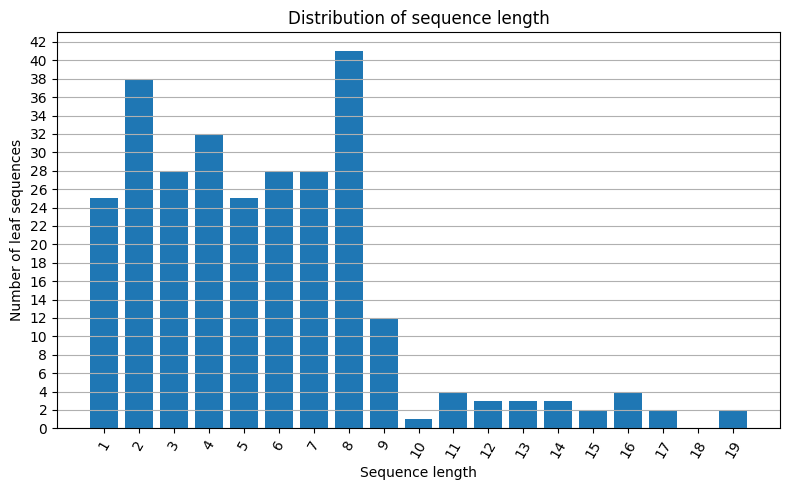

In [92]:
plt.figure(figsize=(8, 5))
plt.bar(info['timepoint_distribution'].keys(), info['timepoint_distribution'].values())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xticks(range(min(info['timepoint_distribution'].keys()), max(info['timepoint_distribution'].keys())+1), rotation=60)
plt.grid(axis='y')
plt.xlabel('Sequence length')
plt.ylabel('Number of leaf sequences')
plt.title('Distribution of sequence length')
plt.tight_layout()

In [93]:
leaf_dataset = LeafSequencesDataset(
    dataset_path, 
    min_timepoints=2, # for analysis of sequences let's get minimum seq length of 2
)
print(f"Number of leaf timeseries: {len(leaf_dataset)}")

Number of leaf timeseries: 256


In [94]:
# Examine a single leaf timeseries
leaf_sample = leaf_dataset[0]
print(f"Leaf sequence: {leaf_sample['sequence_name']}")
print(f"Leaf ID: {leaf_sample['leaf_id']}")
print(f"Number of timepoints: {len(leaf_sample['timepoints'])}")

# Check each timepoint for dense data availability
for i, tp in enumerate(leaf_sample['timepoints']):
    regular_count = tp['points'].shape[0] if tp['points'] is not None else 0
    dense_count = tp['dense_points'].shape[0] if tp['dense_points'] is not None else 0
    print(f"  Day {tp['day']}: {regular_count} regular points, {dense_count} dense points")

Leaf sequence: maize_control_plant1
Leaf ID: 1
Number of timepoints: 9
  Day 0: 5594 regular points, 155504 dense points
  Day 1: 3544 regular points, 171870 dense points
  Day 2: 2445 regular points, 103020 dense points
  Day 3: 1662 regular points, 111073 dense points
  Day 4: 1221 regular points, 59379 dense points
  Day 5: 928 regular points, 33723 dense points
  Day 6: 777 regular points, 50905 dense points
  Day 7: 325 regular points, 13189 dense points
  Day 8: 445 regular points, 48028 dense points


In [95]:
# Number of leaf sequences that have dense point clouds
len(leaf_dataset.get_timeseries_by_crop("maize")) + len(leaf_dataset.get_timeseries_by_crop("tomato2"))

38

In [96]:
# Count leaves with dense point clouds
sequences_with_dense_points = 0
scans_with_dense_points = 0
total_scans = 0

for seq in leaf_dataset:
    scans_with_dense_points_in_seq = 0
    for scan in seq['timepoints']:
        total_scans += 1
        if scan['dense_points'] is not None:
            scans_with_dense_points += 1
            scans_with_dense_points_in_seq += 1
    if scans_with_dense_points_in_seq == len(seq['timepoints']):
        sequences_with_dense_points += 1

print(f"Number of sequences with dense point clouds: {sequences_with_dense_points}")
print(f"Total number of leaves: {total_scans}")
print(f"Number of scans with dense point clouds: {scans_with_dense_points}")
print(f"Percentage of scans with dense points: {scans_with_dense_points/total_scans*100:.1f}%")

Number of sequences with dense point clouds: 38
Total number of leaves: 1550
Number of scans with dense point clouds: 219
Percentage of scans with dense points: 14.1%
